<br/>

<div align="center">
<span style="font-size: 2.5em;">Euclidean & Mahalanobis Distance Analysis</span>
<br/>
<span style="font-size: 1.2em; color: gray;">Assessing learned posterior quality through parametric distances</span>
</div>

## Overview

This notebook evaluates posterior *location accuracy* and *uncertainty-aware accuracy* using Euclidean and Mahalanobis distances. Both metrics compare the inferred posterior to the true parameter point $(\log_{10} m, \log_{10} c_p)$, but they answer different questions.

### Euclidean Distance (location accuracy)

We measure how far the posterior estimate is from the truth in parameter space:

$$
 d_{\mathrm{Eucl}}(\theta_{\mathrm{true}}, \hat{\theta})
 = \left\| \hat{\theta} - \theta_{\mathrm{true}} \right\|_2
$$

- $\hat{\theta}$ can be the **MAP** or **posterior mean** (here we use the MAP in the metric implementation).
- Interpretable in the same units as the parameters (log-space).
- **Ignores posterior width**: a sharp but biased posterior and a broad posterior can have the same Euclidean distance.

### Mahalanobis Distance (accuracy relative to uncertainty)

This distance accounts for posterior covariance $\Sigma$:

$$
 d_{\mathrm{Maha}}(\theta_{\mathrm{true}}, \hat{\theta})
 = \sqrt{(\hat{\theta} - \theta_{\mathrm{true}})^T \Sigma^{-1} (\hat{\theta} - \theta_{\mathrm{true}})}
$$

- Normalizes the error by the posterior uncertainty.
- **Calibration check**: if posteriors are well calibrated and approximately Gaussian, we expect $d_{\mathrm{Maha}} \sim O(1)$.
- Large values indicate either **bias** or **overconfident (too narrow)** posteriors.

### Practical Interpretation

- **Low Euclidean + low Mahalanobis**: accurate and well calibrated.
- **Low Euclidean + high Mahalanobis**: accurate but overconfident (too narrow).
- **High Euclidean + low Mahalanobis**: broad posterior, not very informative.
- **High Euclidean + high Mahalanobis**: biased and overconfident.

### Note on Exclusion Regions

In regions with few or zero events, posterior means and covariances are not meaningful. This can inflate distances. We therefore compare both **with** and **without** zero-event spectra to separate exclusion-region artifacts from genuine calibration issues.

In [ ]:
# =============================
# IMPORTS AND PATH SETTINGS
# =============================

import os, sys
desired_root_name = "xenon-sbi"  
while os.path.basename(os.getcwd()) != desired_root_name:
    os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..")))

import torch

from configs.config import load_model, PARAM_RANGES
from utils.processing import load_matching_pairs
from performances.metrics import euclidean_mahalanobis_eval, plot_mahalanobis_diagnostics

## Model Configuration

Specify the model architecture, halo assumption, and data parameters for evaluation.

In [2]:
# ===========================================
# PARAMETERS TO DEFINE THE DATA AND MODEL 
# ===========================================

modelname = "ntothighest"          
halo      = "default"       
datatag   = "low"
n_train   = 300_000
top_k     = 10              

logm_range = PARAM_RANGES[datatag]["logm_range"]
logcp_range = PARAM_RANGES[datatag]["logcp_range"]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Data and Model Loading

Load the trained model and prepare dataloaders for evaluation.

In [3]:
# =============================
# LOAD MODEL AND CHECKPOINT
# =============================

MODELPATH = f"models/wimpy/{halo}/{modelname}_n{n_train}_{datatag}_{halo}.pt"

model, ckpt = load_model(MODELPATH, modelname, print_arch=False)
print(f"Loading model from:\n{MODELPATH}\n")

Loading model from:
models/wimpy/default/ntothighest_n300000_low_default.pt



In [4]:
# =====================================
# LOAD VALIDATION DATA
# =====================================

X_val, T_val = load_matching_pairs(halo_choice=halo, n_train=n_train, datatag=datatag, split="val")

Loading dataset from:
data/datasets/wimpy/default/wimpy_n300000_low_default.pt



## Part 1: Analysis Including Null Events

In this first part, we evaluate distances **without filtering out zero-event spectra**. This is important to understand the behavior of distance metrics in exclusion regions where no events are detected.

In [5]:
results_with_nulls = euclidean_mahalanobis_eval(
    model=model,
    X_test=X_val,
    T_test=T_val,
    logm_range=logm_range,
    logcp_range=logcp_range,
    posteriorbins=100,
    device=device,
    n_samples=2000, 
    exclude_zero_event_spectra=False
)

### Euclidean Distance (with null events)

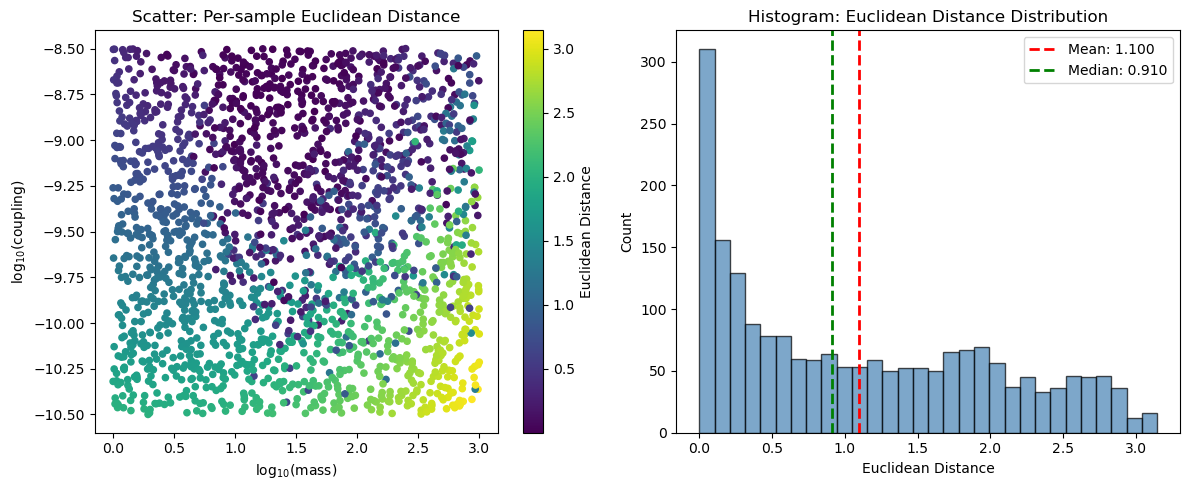

In [7]:
plot_mahalanobis_diagnostics(results_with_nulls, distance_type="euclidean", bins=30)

### Mahalanobis Distance (with null events)

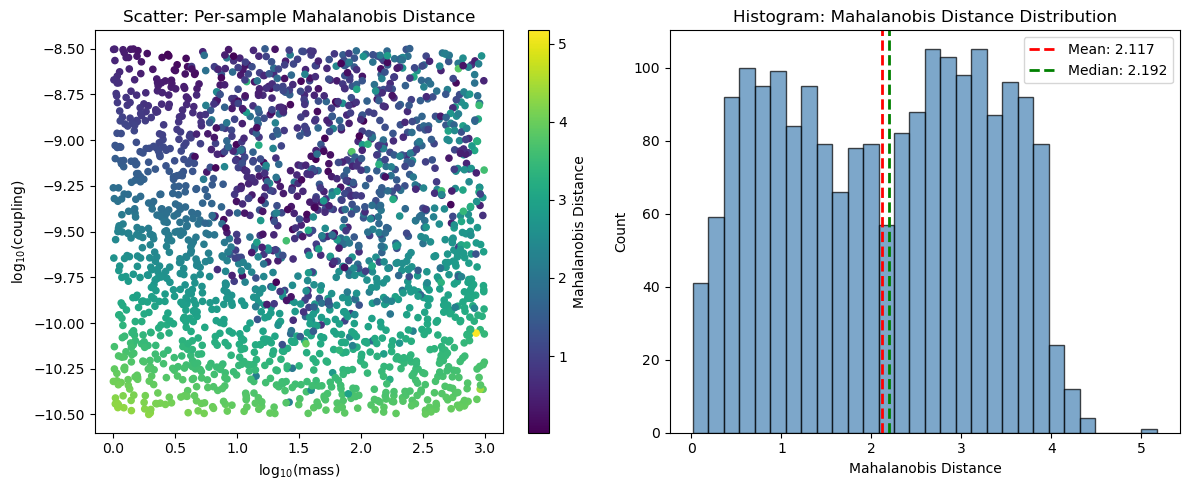

In [8]:
plot_mahalanobis_diagnostics(results_with_nulls, distance_type="mahalanobis", bins=30)

## Observations: Why Distances are Large in Exclusion Regions

**Key findings from the analysis with null events:**

1. **Mahalanobis Distances >> 1**: The mean/median Mahalanobis distances are much larger than 1, indicating **poor posterior calibration**. This suggests the learned posteriors are either:
   - Overconfident (too narrow) compared to the true posterior width
   - Severely biased away from the true parameters
   - Both

2. **Why this happens in exclusion regions**:
   - In the **exclusion region** (low event counts or zero events), there is little statistical information to constrain the posterior
   - The learned network still produces a posterior, but with meaningless statistics
   - The posterior mean and covariance are not well-grounded in these regions
   - Distance metrics become dominated by the exclusion zone behavior

3. **Motivation for filtering**: 
   - Distances in exclusion regions (zero or near-zero counts) are **not meaningful** indicators of posterior quality
   - These regions don't represent useful detection scenarios
   - To fairly assess posterior calibration, we should only evaluate in regions where data actually constrains the parameters

**This motivates the next analysis where we exclude null-event spectra.**

## Part 2: Analysis Excluding Null Events

Now we repeat the analysis **filtering out zero-event spectra**. This allows us to fairly evaluate posterior calibration in the parameter space regions where the data actually constrains the posterior.

In [9]:
results_filtered = euclidean_mahalanobis_eval(
    model=model,
    X_test=X_val,
    T_test=T_val,
    logm_range=logm_range,
    logcp_range=logcp_range,
    posteriorbins=100,
    device=device,
    n_samples=2000, 
    exclude_zero_event_spectra=True
)

### Euclidean Distance (without null events)

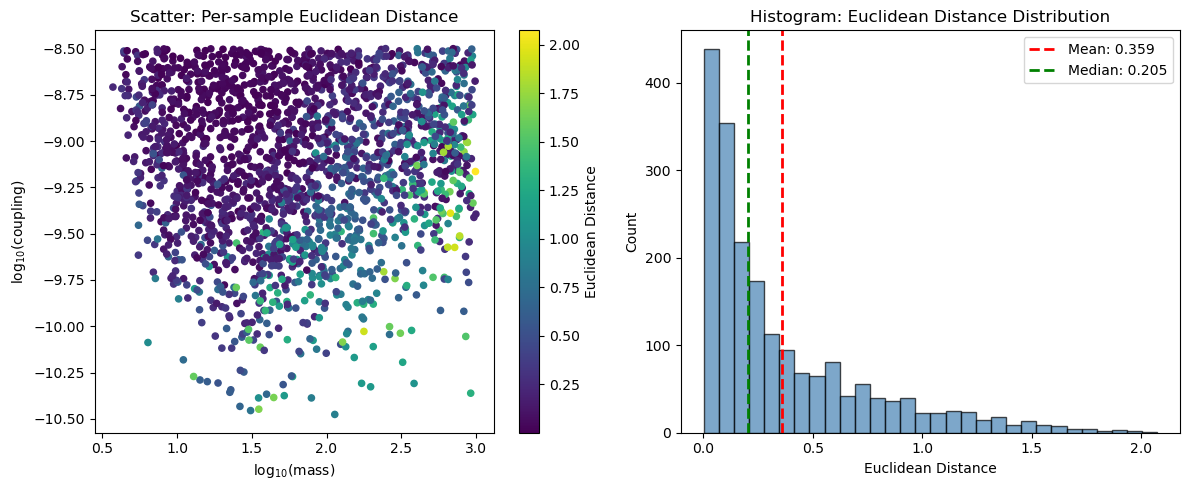

In [10]:
plot_mahalanobis_diagnostics(results_filtered, distance_type="euclidean", bins=30)

### Mahalanobis Distance (without null events)

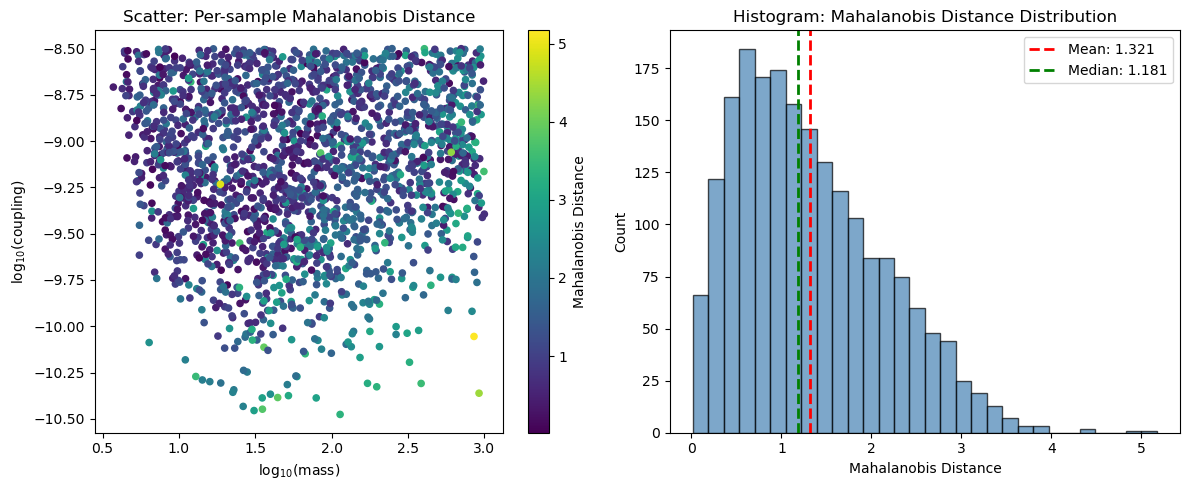

In [11]:
plot_mahalanobis_diagnostics(results_filtered, distance_type="mahalanobis", bins=30)

## Summary

**Key Findings:**

1. **With null events**: Large distances (especially Mahalanobis >> 1) indicate poor calibration in exclusion regions where no meaningful posterior information can be learned.

2. **Without null events**: After filtering, distances should be **significantly smaller** and Mahalanobis values closer to 1, indicating better posterior calibration in regions with actual constraints.

3. **Interpretation**: 
   - The reduction in Mahalanobis distances demonstrates that poor calibration was primarily driven by exclusion region behavior
   - In signal regions with actual events, the posterior should be better calibrated to the true parameters
   - This validates the need to evaluate posterior calibration only in regions where the data provides signal strength

4. **Comparison to JSD**:
   - JSD was especially large when posteriors were small
   - Here, Euclidean distance (and to a lesser extent Mahalanobis) is larger when posteriors are large, and smaller when posteriors are small
   - Thus, parameter regions that generate only a few events tend to show larger distances